In [1]:
!rm -rf /content/runs

In [2]:
pip install ultralytics ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 74.9 MB/s eta 0:00:00


In [3]:
pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 30.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [4]:
from roboflow import Roboflow

rf = Roboflow(api_key="secret")
project = rf.workspace("university-of-toronto-xho85").project("numberdetection-eppfj")
version = project.version(2)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to numberdetection-2 in yolov11:: 100%|██████████| 2374/2374 [00:00<00:00, 5274.67it/s]


In [5]:
from roboflow import Roboflow

rf = Roboflow(api_key="secret")
project = rf.workspace("soumyadeep-dutta").project("yolov5-svhn")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to YOLOv5-SVHN-1 in yolov11:: 100%|██████████| 19988/19988 [00:02<00:00, 8623.79it/s]


In [6]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt").to("cuda")
model.train(
    data="numberdetection-2/data.yaml",
    epochs=5,
    batch=16,
    imgsz=640,
    workers=2,
    patience=3,
    lr0=0.001,
)
model = YOLO("runs/detect/train/weights/best.pt")
model.train(
    data="YOLOv5-SVHN-1/data.yaml",
    epochs=15,
    batch=16,
    imgsz=416,
    workers=2,
    patience=5,
    lr0=0.001
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=numberdetection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_r

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b575e75b3b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

In [1]:
from ultralytics import YOLO

model = YOLO("best.pt").to("mps")
metrics = model.val(data="YOLOv5-SVHN-1/data.yaml", split="test", plots=True)

# Map50 > 0.6 – соблюдено условие задачи на уровень Map (из чата)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

YOLO11s summary (fused): 101 layers, 9,416,670 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 26.0±10.3 MB/s, size: 4.7 KB)
val: Scanning /Users/fireguy/PycharmProjects/CVLab/lab2/YOLOv5-SVHN-1/test/labels.cache... 999 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 999/999 139.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 2.3it/s 27.8s0.3ss
                   all        999       2184      0.867      0.789      0.878      0.438
                     1        372        441      0.837      0.744      0.821      0.342
                    10        146        155       0.94      0.802       0.91      0.457
                     2        268        301      0.896      0.883      0.939       0.48
                     3        222        244      0.851      0.742      0.832      0.432
                     4        208        219      0.859      0.807      0.889      0.43

In [2]:
results = model.predict(
    source="YOLOv5-SVHN-1/test/images",
    save=True,
    save_txt=True,
    plots=True,
    imgsz=416
)


image 1/999 /Users/fireguy/PycharmProjects/CVLab/lab2/YOLOv5-SVHN-1/test/images/10012_png.rf.782a74c5fffb05d2dfeefe12e38bbe1f.jpg: 416x416 1 2, 1 8, 13.3ms
image 2/999 /Users/fireguy/PycharmProjects/CVLab/lab2/YOLOv5-SVHN-1/test/images/1007_png.rf.b3ee53f54eb9b718e8166f64042ca736.jpg: 416x416 1 1, 1 5, 18.2ms
image 3/999 /Users/fireguy/PycharmProjects/CVLab/lab2/YOLOv5-SVHN-1/test/images/10119_png.rf.eefef57c5d0bf5fb02963fe95f66193c.jpg: 416x416 1 5, 1 6, 16.8ms
image 4/999 /Users/fireguy/PycharmProjects/CVLab/lab2/YOLOv5-SVHN-1/test/images/10137_png.rf.a19edee229351200d68c6b684c704084.jpg: 416x416 1 1, 1 5, 1 8, 16.0ms
image 5/999 /Users/fireguy/PycharmProjects/CVLab/lab2/YOLOv5-SVHN-1/test/images/10202_png.rf.e290f9c505f33806831e7581a54f9312.jpg: 416x416 1 4, 17.8ms
image 6/999 /Users/fireguy/PycharmProjects/CVLab/lab2/YOLOv5-SVHN-1/test/images/10222_png.rf.28c5fbc2d4419f4e5b7a1afe59a99b95.jpg: 416x416 1 4, 17.3ms
image 7/999 /Users/fireguy/PycharmProjects/CVLab/lab2/YOLOv5-SVHN-1/t

Cur dir: ./runs/detect/predict/labels


100%|██████████| 961/961 [00:00<00:00, 7116.11it/s]


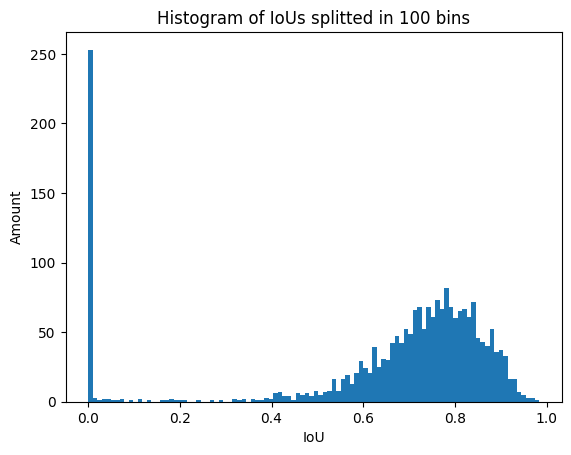

Total amount of zeros: 251
Total amount of non-zeros: 1905
Average IoU: 0.6495339694511082


In [3]:
%matplotlib inline

import torch
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

def box_iou(box1, box2):
    xi1 = max([box1[0], box2[0]])
    yi1 = max([box1[1], box2[1]])
    xi2 = min([box1[2], box2[2]])
    yi2 = min([box1[3], box2[3]])

    inter_area = max([(xi2 - xi1), 0]) * max([(yi2 - yi1), 0])
    box1_area = (box1[2]-box1[0]) * (box1[3]-box1[1])
    box2_area = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area

def get_boxes(file):
    boxes = dict()
    with open(file, "r") as f:
        for line in f.readlines():
            cls, xc, yc, w, h = map(float, line.strip().split())
            x1 = xc - w/2
            y1 = yc - h/2
            x2 = xc + w/2
            y2 = yc + h/2
            if cls not in boxes:
                boxes[cls] = []
            boxes[cls].append((x1, y1, x2, y2))
    return boxes

def count_iou(pred_path, gt_path):
    ious = []
    for root, dirs, files in os.walk(pred_path):
        print(f"Cur dir: {root}")
        for file in tqdm(files):
            boxes_pred = get_boxes(os.path.join(root, file))
            boxes_gt = get_boxes(os.path.join(gt_path, file))
            for cur_cls, cur_pred_boxes in boxes_pred.items():
                for pred_box in cur_pred_boxes:
                    this_box_ious = [0]
                    if cur_cls in boxes_gt:
                        for gt_box in boxes_gt[cur_cls]:
                            this_box_ious.append(box_iou(pred_box, gt_box))
                    ious.append(max(this_box_ious))
    return ious


pred_ious = count_iou("./runs/detect/predict/labels", "./YOLOv5-SVHN-1/test/labels")
plt.hist(pred_ious, bins=100)
plt.xlabel("IoU")
plt.ylabel("Amount")
plt.title("Histogram of IoUs splitted in 100 bins")
plt.show()
print(f"Total amount of zeros: {sum([i == 0 for i in pred_ious])}")
print(f"Total amount of non-zeros: {sum([i != 0 for i in pred_ious])}")
print(f"Average IoU: {sum(pred_ious)/len(pred_ious)}")

In [4]:
model = YOLO("best.pt").to("mps")

results = model.predict(
    source="./myimages",
    save=True,
    save_txt=True,
    plots=True,
    conf=0.4,
    imgsz=4032,
)


image 1/5 /Users/fireguy/PycharmProjects/CVLab/lab2/myimages/IMG_8439.jpg: 4032x3040 18 1s, 27 10s, 5 2s, 2 4s, 1 5, 8 6s, 1 7, 1 8, 2 9s, 622.0ms
image 2/5 /Users/fireguy/PycharmProjects/CVLab/lab2/myimages/IMG_8647.jpg: 4032x3040 1 1, 1 2, 275.7ms
image 3/5 /Users/fireguy/PycharmProjects/CVLab/lab2/myimages/IMG_8660.jpg: 4032x3040 2 1s, 15 10s, 8 2s, 1 3, 4 6s, 2 7s, 1 9, 264.5ms
image 4/5 /Users/fireguy/PycharmProjects/CVLab/lab2/myimages/IMG_8686.jpeg: 4032x3040 4 1s, 4 10s, 1 3, 3 4s, 1 5, 2 6s, 1 7, 2 8s, 1 9, 270.5ms
image 5/5 /Users/fireguy/PycharmProjects/CVLab/lab2/myimages/IMG_8688.jpg: 4032x3040 15 1s, 10 10s, 3 2s, 6 3s, 3 4s, 1 5, 4 6s, 6 7s, 3 8s, 1 9, 266.5ms
Speed: 27.6ms preprocess, 339.8ms inference, 107.7ms postprocess per image at shape (1, 3, 4032, 3040)
Results saved to /Users/fireguy/PycharmProjects/CVLab/lab2/runs/detect/predict2
5 labels saved to /Users/fireguy/PycharmProjects/CVLab/lab2/runs/detect/predict2/labels
